# QICK-DAWG Demo Notebook with Fine Resolution Timing (200 ps)

This notebook is an extension of the counting demo for QICK-DAWG, covering fine timing sequences.

Our instrumentation setup, used for this notebook, is an RFSoC4x2 modified as shown in the demo. Additional setup includes:

- Our microwave output is connected to QICK channel 0, to a microwave amplifier, to a wirebond. 
- Our readout is a Avalanche Photodiode Module, which is connected to the input to QICK.
- Our laser is gated by PMOD channel 0 which is connected to a an AOM driver.

In [210]:
# (requires) setup.py, run to show version of qickdawg installed
!pip show qickdawg

Could not import runpy._run_module_as_main
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1371, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1342, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 938, in _load_unlocked
  File "<frozen importlib._bootstrap>", line 1179, in exec_module
  File "<frozen runpy>", line 14, in <module>
  File "C:\Users\QT3 User Facility\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\importlib\__init__.py", line 57, in <module>
    import warnings
  File "C:\Users\QT3 User Facility\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\warnings.py", line 574, in <module>
    filterwarnings("default", category=DeprecationWarning,
  File "C:\Users\QT3 User Facility\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\warnings.py", line 153, in filterwarnings
    import re
  File "C:\Users\QT3 User Facility\AppData\Roaming\uv\python\cpython-3.11-windows-x86

In [211]:
%load_ext autoreload
%autoreload 2
# %matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from importlib.metadata import version
version('numpy')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'1.26.4'

In [212]:
# FIXME: Delete this cell before submitting
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

# Test
!pip --version

Could not import runpy._run_module_as_main
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1371, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1342, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 938, in _load_unlocked
  File "<frozen importlib._bootstrap>", line 1179, in exec_module
  File "<frozen runpy>", line 14, in <module>
  File "C:\Users\QT3 User Facility\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\importlib\__init__.py", line 57, in <module>
    import warnings
  File "C:\Users\QT3 User Facility\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\warnings.py", line 574, in <module>
    filterwarnings("default", category=DeprecationWarning,
  File "C:\Users\QT3 User Facility\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\warnings.py", line 153, in filterwarnings
    import re
  File "C:\Users\QT3 User Facility\AppData\Roaming\uv\python\cpython-3.11-windows-x86

In [213]:
# TODO: Update the IP address to match your setup
qd.start_client('192.168.3.1')

In [214]:
default_config = qd.NVConfiguration()
# TODO: Set all of these parameters based on your setup and experiment goals.

# Hardware channels
default_config.mw_channel = 0
default_config.adc_channel = 0
default_config.laser_gate_pmod = 0       # PMOD0_0

# Photon Counting Params
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500

# MW pulse parameters
default_config.mw_pi2_ftns = 24.7     
default_config.mw_pi_ftns = 49.4
default_config.mw_nqz = 1
default_config.mw_fMHz = 1845.8
default_config.mw_gain = 32767            # NOTE: Adjust based on your Amplifier

# Timing delays
default_config.mw_to_laser_delay_tns = 555 # Laser turn-on lag relative to MW
default_config.relax_delay_tus = 2        # Spin relaxation delay

# Readout timing
default_config.laser_on_tus = 6
default_config.readout_reference_start_tus = 5
# NOTE: The following are determined from the CD experiment
default_config.readout_integration_tns = 633
default_config.laser_readout_offset_tus = 1.159 

# Experiment control
default_config.reps = 10000
default_config.pre_init = True
default_config.get_reference = True       # If True, collect MW-off reference readouts

### Laser On / Off

In [215]:
qd.laser_on(copy(default_config))

2

In [216]:
qd.laser_off(copy(default_config))

0

# Counting Duration
NOTE: Determine pi pulse frequency andduration before dialing this in  

In [199]:
from qickdawg.finetimingsuite.counting_duration_fine_res import CountingDurationFineRes

config = copy(default_config)

config.readout_integration_tns = 10
config.reps = 200000

delays = np.arange(default_config.laser_readout_offset_tns - 400, default_config.laser_readout_offset_tns+1000, 10)

def _as_scalar(value):
    arr = np.asarray(value).squeeze()
    if arr.size == 1:
        return float(arr)
    return float(np.mean(arr))

# FIXME: Discard one dummy acquisition before storing data.
config.laser_readout_offset_tns = int(delays[0])
_ = CountingDurationFineRes(config).acquire()

cd_data = None
for i in delays:
    config.laser_readout_offset_tns = int(i)

    prog = CountingDurationFineRes(config)
    d = prog.acquire()

    if cd_data is None:
        cd_data = copy(d)
        for key in d.keys():
            cd_data[key] = np.array([_as_scalar(d[key])], dtype=float)
        cd_data.delay = np.array([config.laser_readout_offset_tus], dtype=int)
    else:
        for key in d.keys():
            cd_data[key] = np.append(cd_data[key], _as_scalar(d[key]))
        cd_data.delay = np.append(cd_data.delay, config.laser_readout_offset_tus)

print(f"Collected {len(cd_data.delay)} points.")

Stored 141 points.


In [224]:
cd_data.delay_tus

array([0.        , 0.76822917, 0.77799479, 0.78776042, 0.79752604,
       0.80729167, 0.81705729, 0.82682292, 0.83658854, 0.84960938,
       0.859375  , 0.86914062, 0.87890625, 0.88867188, 0.8984375 ,
       0.90820312, 0.91796875, 0.92773438, 0.9375    , 0.94726562,
       0.95703125, 0.96679688, 0.9765625 , 0.98958333, 0.99934896,
       1.00911458, 1.01888021, 1.02864583, 1.03841146, 1.04817708,
       1.05794271, 1.06770833, 1.07747396, 1.08723958, 1.09700521,
       1.10677083, 1.11653646, 1.12955729, 1.13932292, 1.14908854,
       1.15885417, 1.16861979, 1.17838542, 1.18815104, 1.19791667,
       1.20768229, 1.21744792, 1.22721354, 1.23697917, 1.24674479,
       1.25651042, 1.26953125, 1.27929688, 1.2890625 , 1.29882812,
       1.30859375, 1.31835938, 1.328125  , 1.33789062, 1.34765625,
       1.35742188, 1.3671875 , 1.37695312, 1.38671875, 1.39648438,
       1.40950521, 1.41927083, 1.42903646, 1.43880208, 1.44856771,
       1.45833333, 1.46809896, 1.47786458, 1.48763021, 1.49739

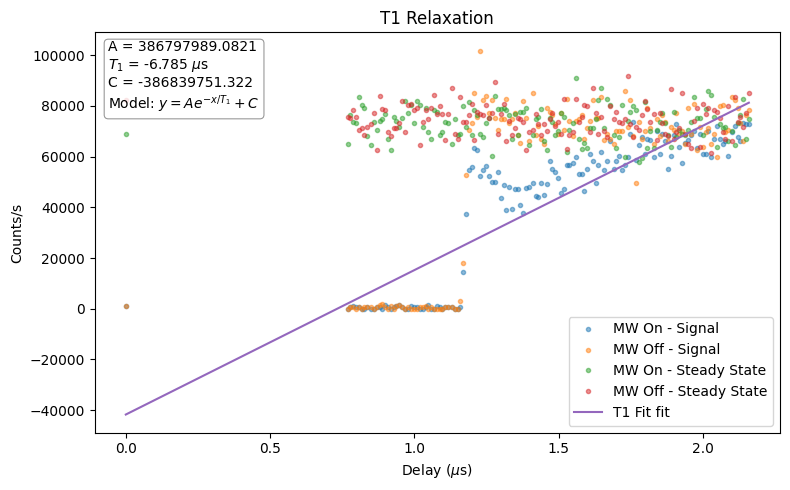

In [223]:
plot_t1 = Visualizer.plot_t1(data=cd_data)

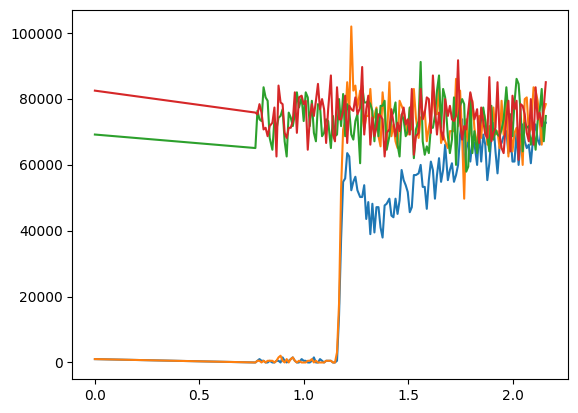

In [200]:
plt.plot(cd_data.delay, cd_data.signal1_cts_s)
plt.plot(cd_data.delay, cd_data.signal2_cts_s)
plt.plot(cd_data.delay, cd_data.reference1_cts_s)
plt.plot(cd_data.delay, cd_data.reference2_cts_s)

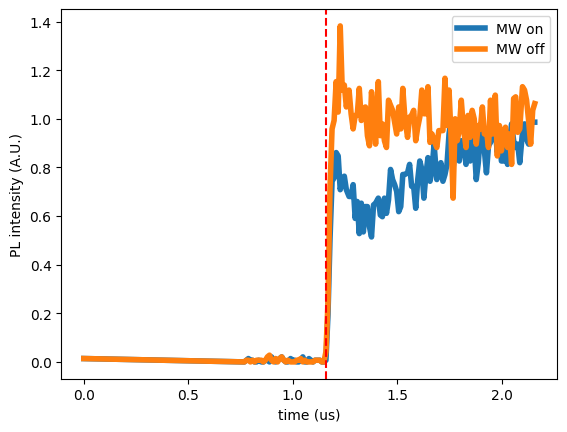

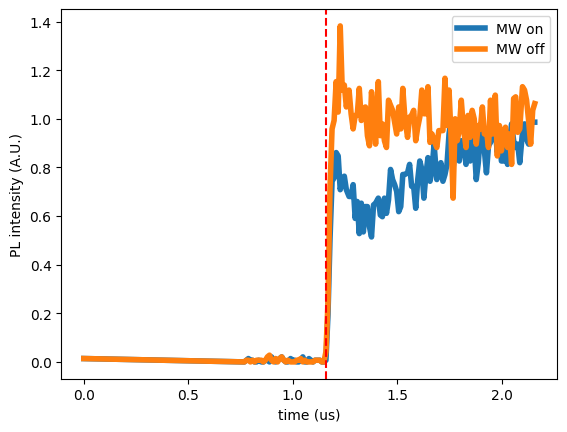

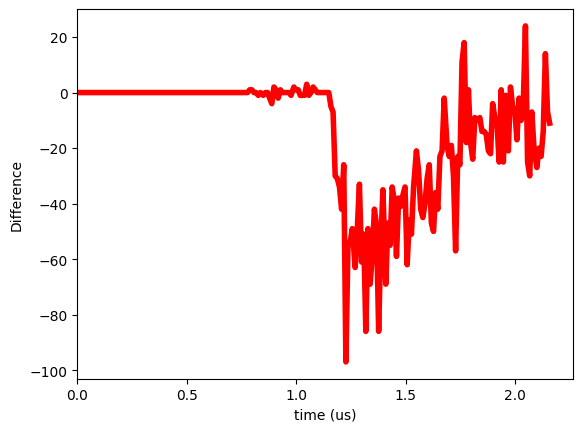

laser_readout_offset is approximately 1.208 us (371 treg)


In [201]:
Visualizer.plot_rabi(data=rabi_data, fit=True)
Visualizer.plot_rabi(data=rabi_data, contrast_mode="signal_over_off", view="contrast")

In [11]:
from qickdawg.finetimingsuite.rabi_fine_res import RabiFineRes

config = copy(default_config)

# config.add_linear_sweep("mw_duration", "ftsamp", start=100, stop=2200, delta=5)
config.add_linear_sweep("mw_duration", "ftns", start=5, stop=500, delta=0.2)
config.mw_gain = 32767
config.mw_fMHz = 1846
config.reps = 300000//2//6

prog = RabiFineRes(config)
rabi_data = prog.acquire(progress=True)


Requested 5 to 500 by 0.2
Instead using 5.086263020833334 to 508.62630208333337 by 0.20345052083333334 in 2476 steps


100%|██████████| 61900000/61900000 [18:11<00:00, 56716.62it/s]


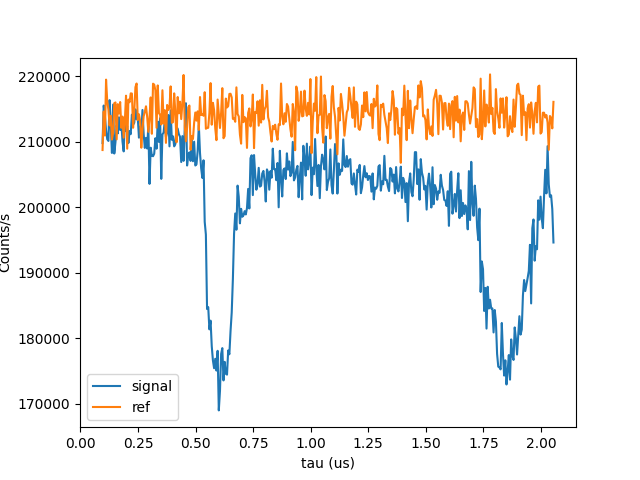

In [ ]:

plt.close()
plt.plot(ftsamp_to_ns(d.tau_ftsamp)/1000, d.signal1_cts_s, label="signal")
plt.plot(ftsamp_to_ns(d.tau_ftsamp)/1000, d.signal2_cts_s, label="ref")
plt.xlabel("tau (us)")
plt.ylabel("Counts/s")
plt.legend()
plt.show()

## Bootstrap

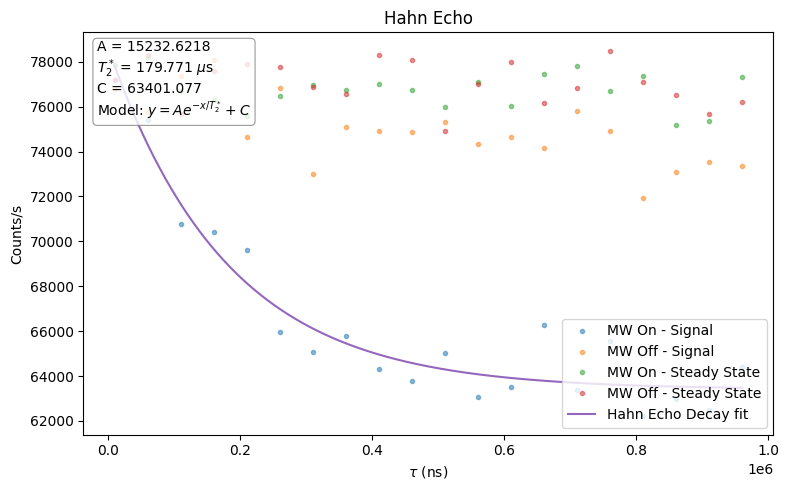

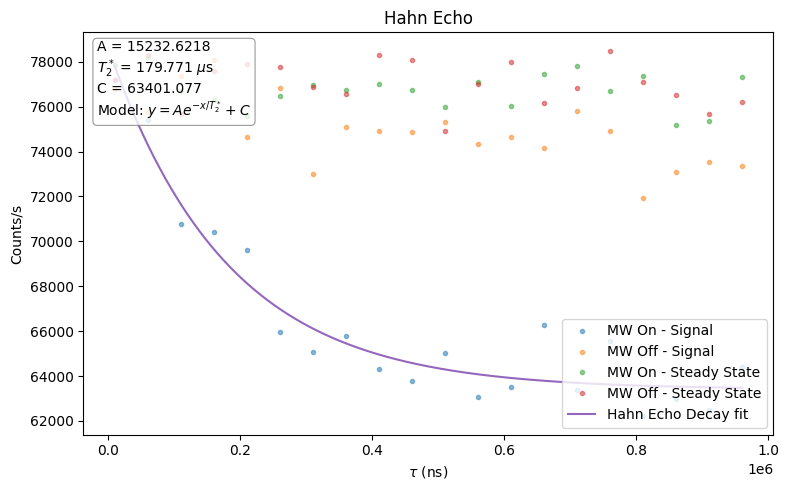

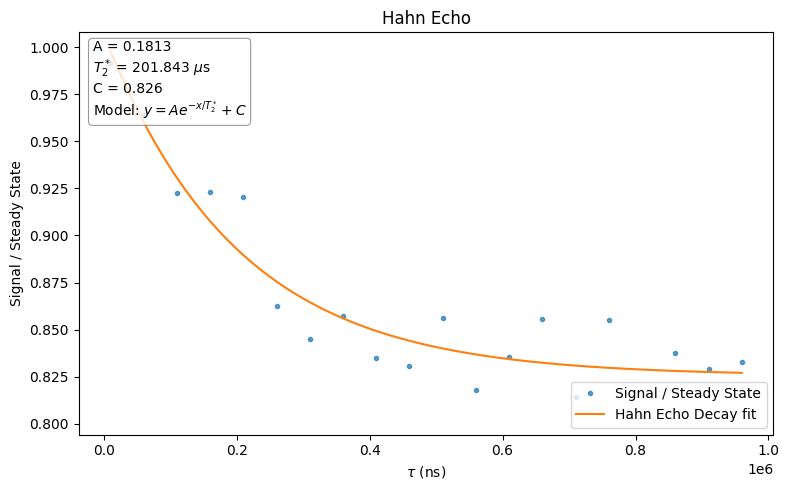

In [179]:
%matplotlib inline

from qickdawg.finetimingsuite.bootstrap_fine_res import BootstrapFineRes

config = copy(default_config)

config.btwn_mw_delay_ftsamp = 100

config.mw_gain = 32767
config.frequency_MHz = 1847

config.reps = 1000000//50

results = None
for bootstrap_index in range(1, 13):
    config.bootstrap_experiment_number = bootstrap_index

    prog = BootstrapFineRes(config)
    d = prog.acquire(progress=True)

    if results is None:
        results = copy(d)
        for key in d.keys():
            results[key] = np.array([_as_scalar(d[key])], dtype=float)
        results.bootstrap_index = np.array([config.bootstrap_experiment_number], dtype=int)
    else:
        for key in d.keys():
            results[key] = np.append(results[key], _as_scalar(d[key]))
        if not hasattr(results, "bootstrap_index"):
            results.bootstrap_index = np.array([], dtype=int)
        results.bootstrap_index = np.append(
            results.bootstrap_index, config.bootstrap_experiment_number
        )

print(f"Stored {len(results.bootstrap_index)} bootstrap points.")

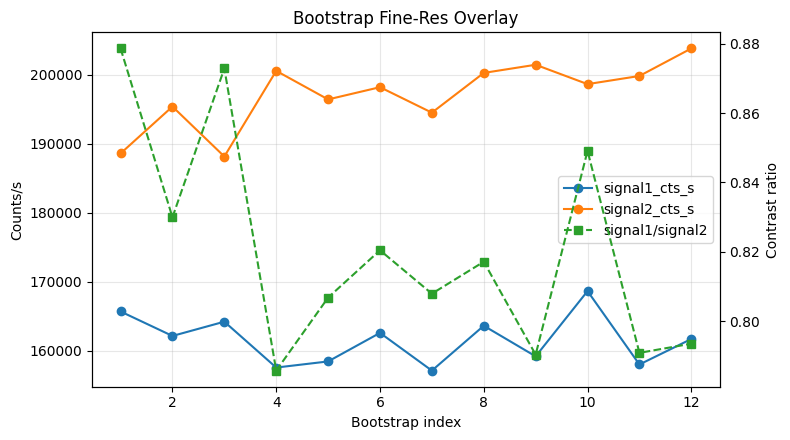

In [34]:
plt.close()

x = np.asarray(results.bootstrap_index, dtype=float)
y1 = np.asarray(results.signal1_cts_s, dtype=float)
y2 = np.asarray(results.signal2_cts_s, dtype=float)
ratio = y1 / np.clip(y2, 1e-12, None)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax2 = ax1.twinx()

l1 = ax1.plot(x, y1, "o-", color="tab:blue", label="signal1_cts_s")
l2 = ax1.plot(x, y2, "o-", color="tab:orange", label="signal2_cts_s")
l3 = ax2.plot(x, ratio, "s--", color="tab:green", label="signal1/signal2")

ax1.set_xlabel("Bootstrap index")
ax1.set_ylabel("Counts/s")
ax2.set_ylabel("Contrast ratio")
ax1.set_title("Bootstrap Fine-Res Overlay")
ax1.grid(alpha=0.3)

lines = l1 + l2 + l3
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")

plt.tight_layout()
plt.show()

# Ramsey

In [ ]:
from qickdawg.finetimingsuite.ramsey_fine_res import RamseyFineRes

config = copy(default_config)

config.add_exponential_sweep('tau', 'ftsamp', start=1000, stop=5000000//20, scaling_factor='3/2')

# config.tau_end_ftsamp = 2500
config.reps = 100000//4

print(config.tau_end_ftus)

prog = RamseyFineRes(config)
d = prog.acquire(progress=True)

50.862630208333336


  0%|          | 0/375000 [00:00<?, ?it/s]

In [ ]:
from qickdawg.finetimingsuite.t1_fine_res import T1FineRes

config = copy(default_config)

config.add_exponential_sweep("tau", "tus", start=10, stop=6000, delta=100)
config.reps = 50000

prog = CPMGXYFineRes(config)
cpmg_data = prog.acquire(progress=True)

In [190]:
from qickdawg.finetimingsuite.cpmg_xy_fine_res import CPMGXYFineRes

config = copy(default_config)

config.add_linear_sweep("tau", "ftns", start=1700, stop=1850, delta=1)

config.n_cpmg = 32
config.reps = 100000


prog = CPMGXYFineRes(config)
cpmg_data2 = prog.acquire(progress=True)


Requested 1700 to 1850 by 1
Instead using 1700.0325520833335 to 1852.6204427083335 by 1.0172526041666667 in 151 steps


  0%|          | 21677/22650000 [00:05<1:37:05, 3884.44it/s]



Requested 1700 to 1850 by 1
Instead using 1700.0325520833335 to 1852.6204427083335 by 1.0172526041666667 in 151 steps


  0%|          | 21677/22650000 [00:05<1:37:05, 3884.44it/s]


KeyboardInterrupt: 